# P1 Milestone: Earthquake Building Damage Grade Prediction

---

Farhan Hamid Lubis  <br>
Hacktiv8 Data Science Fulltime RMT-052 <br>
**Milestone Phase 1 - Multiclass Classification** <br>

Hugging Face: https://huggingface.co/spaces/farhanhl-ds/earthquake-damage-predictor <br>
Dataset: Earthquake Magnitude, Damage and Impact - `csv_building_structure.csv` <br>
Source: https://www.kaggle.com/datasets/arashnic/earthquake-magnitude-damage-and-impact

---
## Background

On April 25, 2015, a catastrophic 7.8 Mw earthquake, known as the **Gorkha Earthquake** struck Nepal, causing one of the worst natural disasters in the country's modern history. The earthquake claimed over **8,700 lives**, injured more than **22,300 people**, and triggered widespread landslides and avalanches across the Kathmandu Valley and surrounding regions. The estimated economic loss reached approximately **USD 7 billion**, with 31 of 75 administrative districts affected and 14 districts declared crisis-hit areas.

In the aftermath, the Government of Nepal, through the National Planning Commission Secretariat and Kathmandu Living Labs, conducted a massive door-to-door post-disaster survey across the **11 most severely affected districts**. The survey covered approximately **762,000 buildings** and **3.6 million residents**, collecting detailed structural, socioeconomic, and demographic information. This survey is recognized as one of the **largest post-disaster datasets ever collected**.

This dataset consists of multiple datasets including:
- csv_building_damage_assessment
- csv_building_ownership_and_use
- csv_building_structure
- csv_household_demographics
- csv_household_earthquake_impact
- csv_household_resources
- csv_individual_demographics
- mapping
- ward_vdcmun_district_name_mapping

The purpose of this project is to classify the level of impact or damage caused by the earthquake on building structures around its epicenter. To achieve this objective, the dataset `csv_building_structure.csv` was selected. This dataset contains detailed structural characteristics of buildings prior to the earthquake, including `foundation type`, `roof type`, `construction materials`, `number of floors`, and `building age`. In addition, it provides the recorded **damage grade** assessed after the event, which serves as the target variable representing the severity of damage experienced by each building.

The implication of this project is that it is expected to support the assessment of building quality in earthquake-prone areas and contribute to disaster mitigation efforts, particularly in evaluating structural vulnerability to potentially destructive earthquakes. This model may be especially useful in scenarios with seismic characteristics similar to major events such as the Nepal earthquake, assuming comparable earthquake patterns and structural risk factors.

**Justification for regions in Indonesia:**

- Indonesia is highly vulnerable to earthquakes and other natural disasters.
- BMKG continuously monitors and reports seismic activity across the country.
- Past events, such as the 2022 Cianjur earthquake, have demonstrated the significant impact of earthquakes on communities and infrastructure.

**This model can be used to:**

- Prioritize areas that require faster emergency response based on predicted damage levels.
- Assist in estimating material losses more efficiently after a disaster.
- Serve as a reference for developing earthquake-resistant building standards in disaster-prone areas.

**With target users:**

The primary users of this model include BNPB teams, Public Works (Dinas PU), and disaster response volunteers who require a rapid assessment tool to evaluate building damage levels in earthquake-affected

---
## Objective

Build a **Multiclass Classification** model to predict the **damage grade** of a building (Grade 1–5) based on its structural characteristics before the earthquake. The five damage grades range from Grade 1 (negligible to slight damage) to Grade 5 (complete destruction).

---
## I. Import Libraries

This section imports all the libraries required for this project.

In [ ]:
# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Resampling
from imblearn.under_sampling import RandomUnderSampler

# Model Saving
import pickle

# Misc
import warnings
warnings.filterwarnings('ignore')

# Visualization style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# Global Seed 
RANDOM_STATE = 7

In [1]:
import sklearn
sklearn.__version__

'1.6.1'

---
## II. Define Custom Functions

This section defines the additional functions utilized in the analysis.

In [ ]:
def cardinality_analysis(df):
    print('Cardinality Analysis:')
    
    unique_counts = df.nunique().sort_values(ascending=False)
    total_rows = len(df)

    print(f"Total rows in dataset: {total_rows}")
    print(f"\n{'Feature':<50} {'Unique':<10} {'Cardinality':<15} {'Data Type':<15}")
    print('-'*90)

    for col, count in unique_counts.items():
        cardinality = count / total_rows

        # Detect data type
        if pd.api.types.is_numeric_dtype(df[col]):
            dtype_label = "Numerical"
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
            dtype_label = "Categorical"
        else:
            dtype_label = str(df[col].dtype)

        # Cardinality category
        if cardinality > 0.80:
            category = "VERY HIGH"
        elif cardinality > 0.5:
            category = "HIGH"
        elif cardinality > 0.1:
            category = "MEDIUM"
        elif count == 1:
            category = "NO VARIATION"
        else:
            category = "LOW"

        print(f"{col:<50} {count:<10} {category:<15} {dtype_label:<15}")

---
## III. Data Loading

This section loads the dataset and performs an initial data inspection.

In [118]:
# Load dataset
df = pd.read_csv('csv_building_structure.csv')

print('Shape dataset:', df.shape)
df.head()

Shape dataset: (762106, 31)


,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,...,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,condition_post_eq,damage_grade,technical_solution_proposed
0,120101000011,12,1207,120703,1,1,9,288,9,9,...,0,0,0,1,0,0,0,Damaged-Used in risk,Grade 3,Major repair
1,120101000021,12,1207,120703,1,1,15,364,9,9,...,0,0,0,1,0,0,0,Damaged-Repaired and used,Grade 5,Reconstruction
2,120101000031,12,1207,120703,1,1,20,384,9,9,...,0,0,0,0,0,0,0,Damaged-Repaired and used,Grade 2,Minor repair
3,120101000041,12,1207,120703,1,1,20,312,9,9,...,0,0,0,0,0,0,0,Damaged-Repaired and used,Grade 2,Minor repair
4,120101000051,12,1207,120703,1,1,30,308,9,9,...,0,0,0,0,0,0,0,Damaged-Repaired and used,Grade 1,Minor repair


In [119]:
# Sampling (optional: dataset contains ~700K rows; resampled for efficiency))
df = df.sample(n=50000, random_state=RANDOM_STATE).reset_index(drop=True)
print('Shape after sampling:', df.shape)

Shape after sampling: (50000, 31)


In [120]:
# Check data types for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   building_id                             50000 non-null  int64 
 1   district_id                             50000 non-null  int64 
 2   vdcmun_id                               50000 non-null  int64 
 3   ward_id                                 50000 non-null  int64 
 4   count_floors_pre_eq                     50000 non-null  int64 
 5   count_floors_post_eq                    50000 non-null  int64 
 6   age_building                            50000 non-null  int64 
 7   plinth_area_sq_ft                       50000 non-null  int64 
 8   height_ft_pre_eq                        50000 non-null  int64 
 9   height_ft_post_eq                       50000 non-null  int64 
 10  land_surface_condition                  50000 non-null  object
 11  fo

In [121]:
# Descriptive statistics for numerical columns
df.describe()

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,...,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.0000,50000.000000,50000.000000,50000.000000,50000.00000
mean,2.611012e+11,25.804320,2586.323900,258637.838200,2.082560,1.237180,24.190140,406.715460,16.027100,9.759440,...,0.800560,0.035080,0.01518,0.022780,0.072720,0.2592,0.079980,0.039600,0.015800,0.01244
std,5.805473e+10,5.812399,581.654039,58165.487608,0.655311,1.061088,65.391083,224.900072,5.487164,8.550632,...,0.399583,0.183984,0.12227,0.149203,0.259679,0.4382,0.271265,0.195019,0.124702,0.11084
min,1.201010e+11,12.000000,1201.000000,120101.000000,1.000000,0.000000,0.000000,70.000000,6.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
25%,2.223030e+11,22.000000,2204.000000,220406.000000,2.000000,0.000000,9.000000,280.000000,12.000000,0.000000,...,1.000000,0.000000,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
50%,2.463080e+11,24.000000,2410.000000,241004.000000,2.000000,1.000000,16.000000,357.000000,16.000000,10.000000,...,1.000000,0.000000,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
75%,3.037040e+11,30.000000,3011.000000,301102.000000,2.000000,2.000000,26.000000,471.000000,18.000000,16.000000,...,1.000000,0.000000,0.00000,0.000000,0.000000,1.0000,0.000000,0.000000,0.000000,0.00000
max,3.667090e+11,36.000000,3611.000000,361108.000000,7.000000,9.000000,999.000000,4500.000000,99.000000,96.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.00000


In [122]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %


In [123]:
# Check for duplicate rows
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


In [124]:
# Ensure all categorical columns are string type (not float/NaN)
cat_cols_all = [
    "land_surface_condition", "foundation_type", "roof_type",
    "ground_floor_type", "other_floor_type", "position",
    "plan_configuration", "condition_post_eq", "damage_grade",
    "technical_solution_proposed"
]
for col in cat_cols_all:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col] = df[col].replace("nan", pd.NA)

# Drop rows where target is NaN
df = df.dropna(subset=["damage_grade"]).reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print("Unique damage_grade:", df["damage_grade"].unique())

Shape after cleaning: (50000, 31)
Unique damage_grade: ['Grade 2' 'Grade 5' 'Grade 1' 'Grade 4' 'Grade 3']


---
## IV. Exploratory Data Analysis (EDA)

This stage aims to understand the characteristics and patterns within the dataset.

### A. Target Variable Distribution

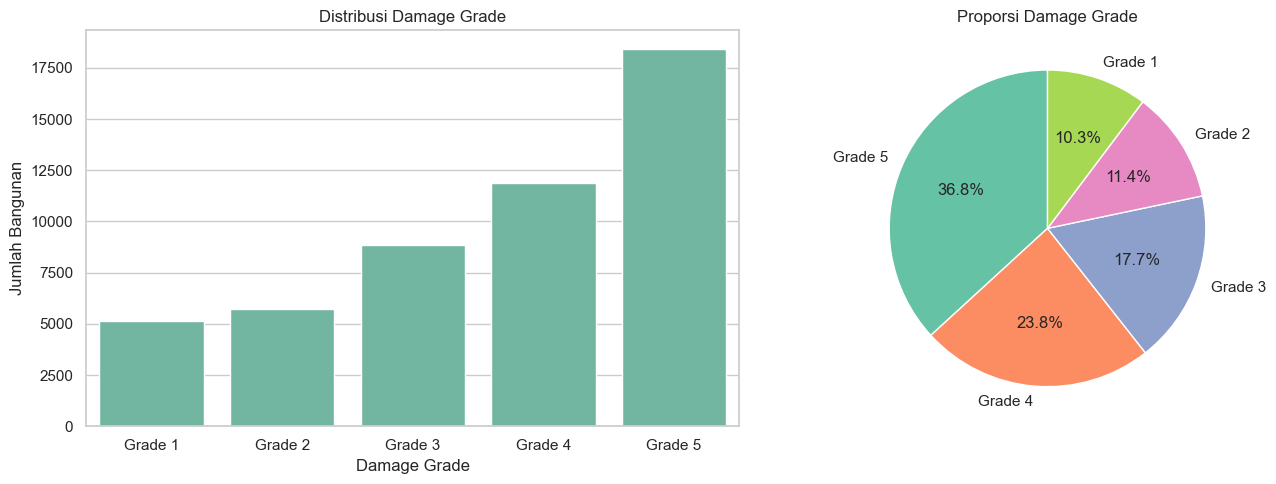

In [152]:
# Distribusi damage_grade (target)
# Clean NaN and ensure string dtype
df = df.dropna(subset=["damage_grade"])
df["damage_grade"] = df["damage_grade"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x="damage_grade", order=sorted(df["damage_grade"].unique()), ax=axes[0])
axes[0].set_title("Distribusi Damage Grade")
axes[0].set_xlabel("Damage Grade")
axes[0].set_ylabel("Jumlah Bangunan")

# Pie chart
grade_counts = df["damage_grade"].value_counts()
axes[1].pie(grade_counts, labels=grade_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporsi Damage Grade")

plt.tight_layout()
plt.show()

#### Insight on Target Variable Distribution

The **damage_grade** distribution reveals a clear class imbalance. **Grade 5** (most severe damage) dominates the dataset at around **36%**, while **Grade 1** (least severe) is the smallest class at roughly **10%**. This pattern reflects the real-world conditions following the 2015 Gorkha Earthquake, where the majority of buildings suffered heavy to total destruction.

Implications for modeling:
- Accuracy is not a reliable metric here. A naive model that always predicts Grade 5 could reach ~36% accuracy without learning anything meaningful.
- **F1-Weighted** is used as the primary metric to balance performance across classes according to their proportions.
- Class imbalance handling (moderate undersampling) is necessary to prevent the model from being biased toward the majority class.

### B. Numerical Features Distribution

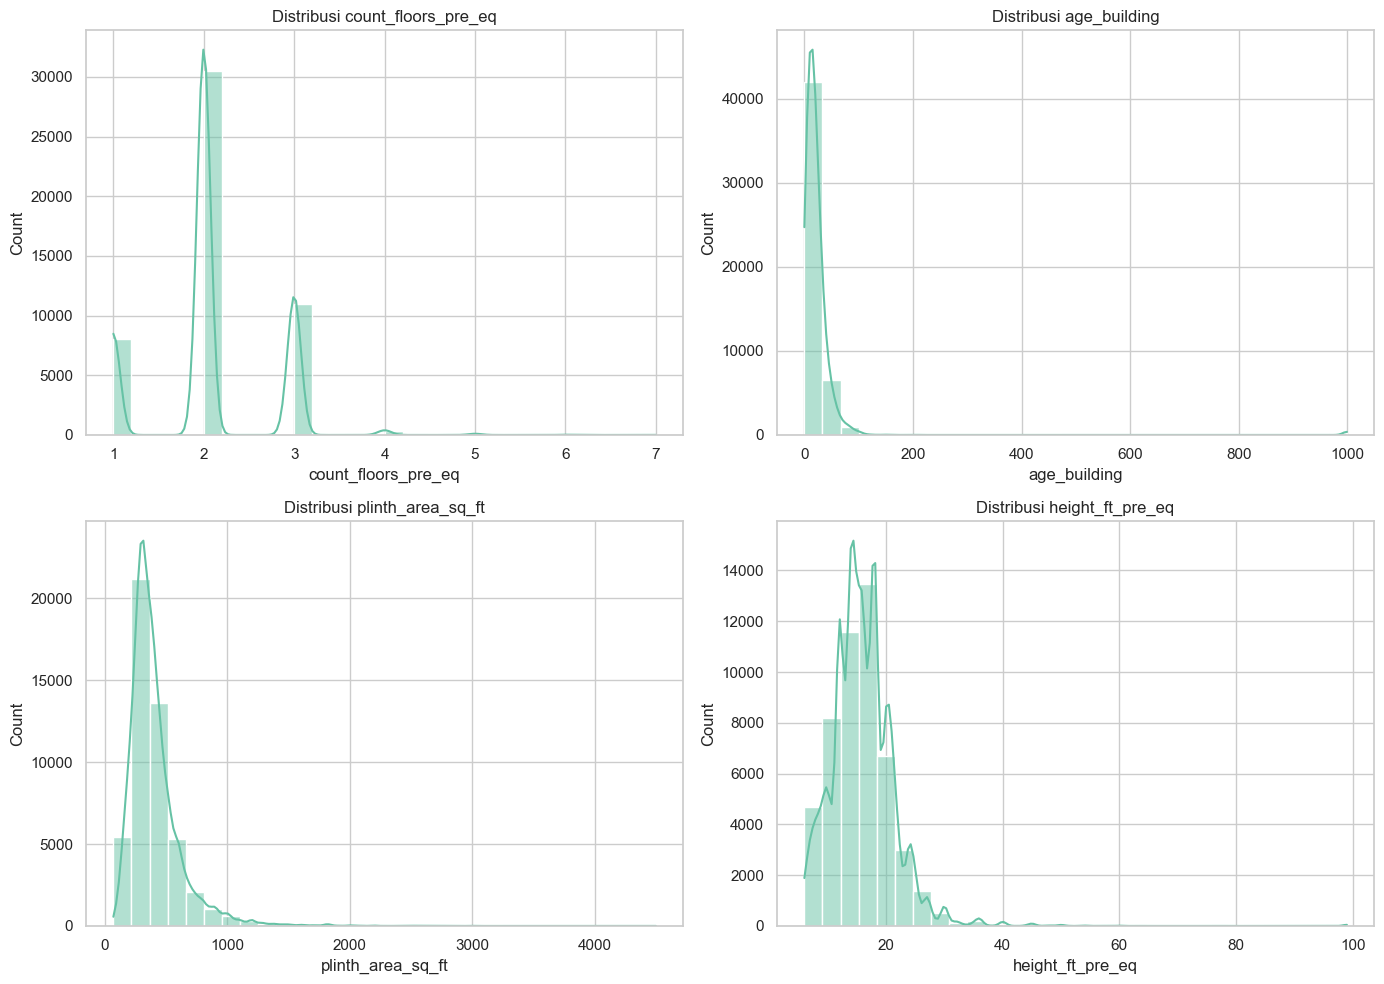

In [ ]:
# Relevant numerical columns (ID columns excluded)
num_cols = ['count_floors_pre_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### Insight on Numerical Features Distribution

All four numerical features show a **right-skewed** distribution:

- **`count_floors_pre_eq`** & **`height_ft_pre_eq`**: The majority of buildings have 1 to 2 floors, with a small number of high-rise outliers. This reflects the typical low-rise residential construction common in Nepal.
- **`age_building`**: Ages are spread across a wide range, with many buildings between 10 and 50 years old. A cluster of very old buildings (over 100 years) is also present, which may be more vulnerable to earthquake damage.
- **`plinth_area_sq_ft`**: Floor area is concentrated at smaller values with a few large outliers, indicating that most buildings are small to medium in size.

Outliers in these features are kept intentionally, as they represent real buildings with valid contextual relevance. Scale differences across features will be handled by **StandardScaler** in the preprocessing pipeline.

**Model selection implication**: <br>
The highly skewed distributions and presence of numerous outliers are important factors when choosing an algorithm. Distance-based or linear models like **KNN** and **SVM** are sensitive to outliers because their calculations are directly influenced by extreme values. In contrast, **tree-based models** (Decision Tree, Random Forest, Gradient Boosting) are naturally robust to outliers since they split on thresholds rather than absolute values, meaning a single extreme value will not distort the overall model. This is one strong reason to prioritize **Random Forest** as the primary model candidate for this dataset.

### C. Categorical Features Distribution

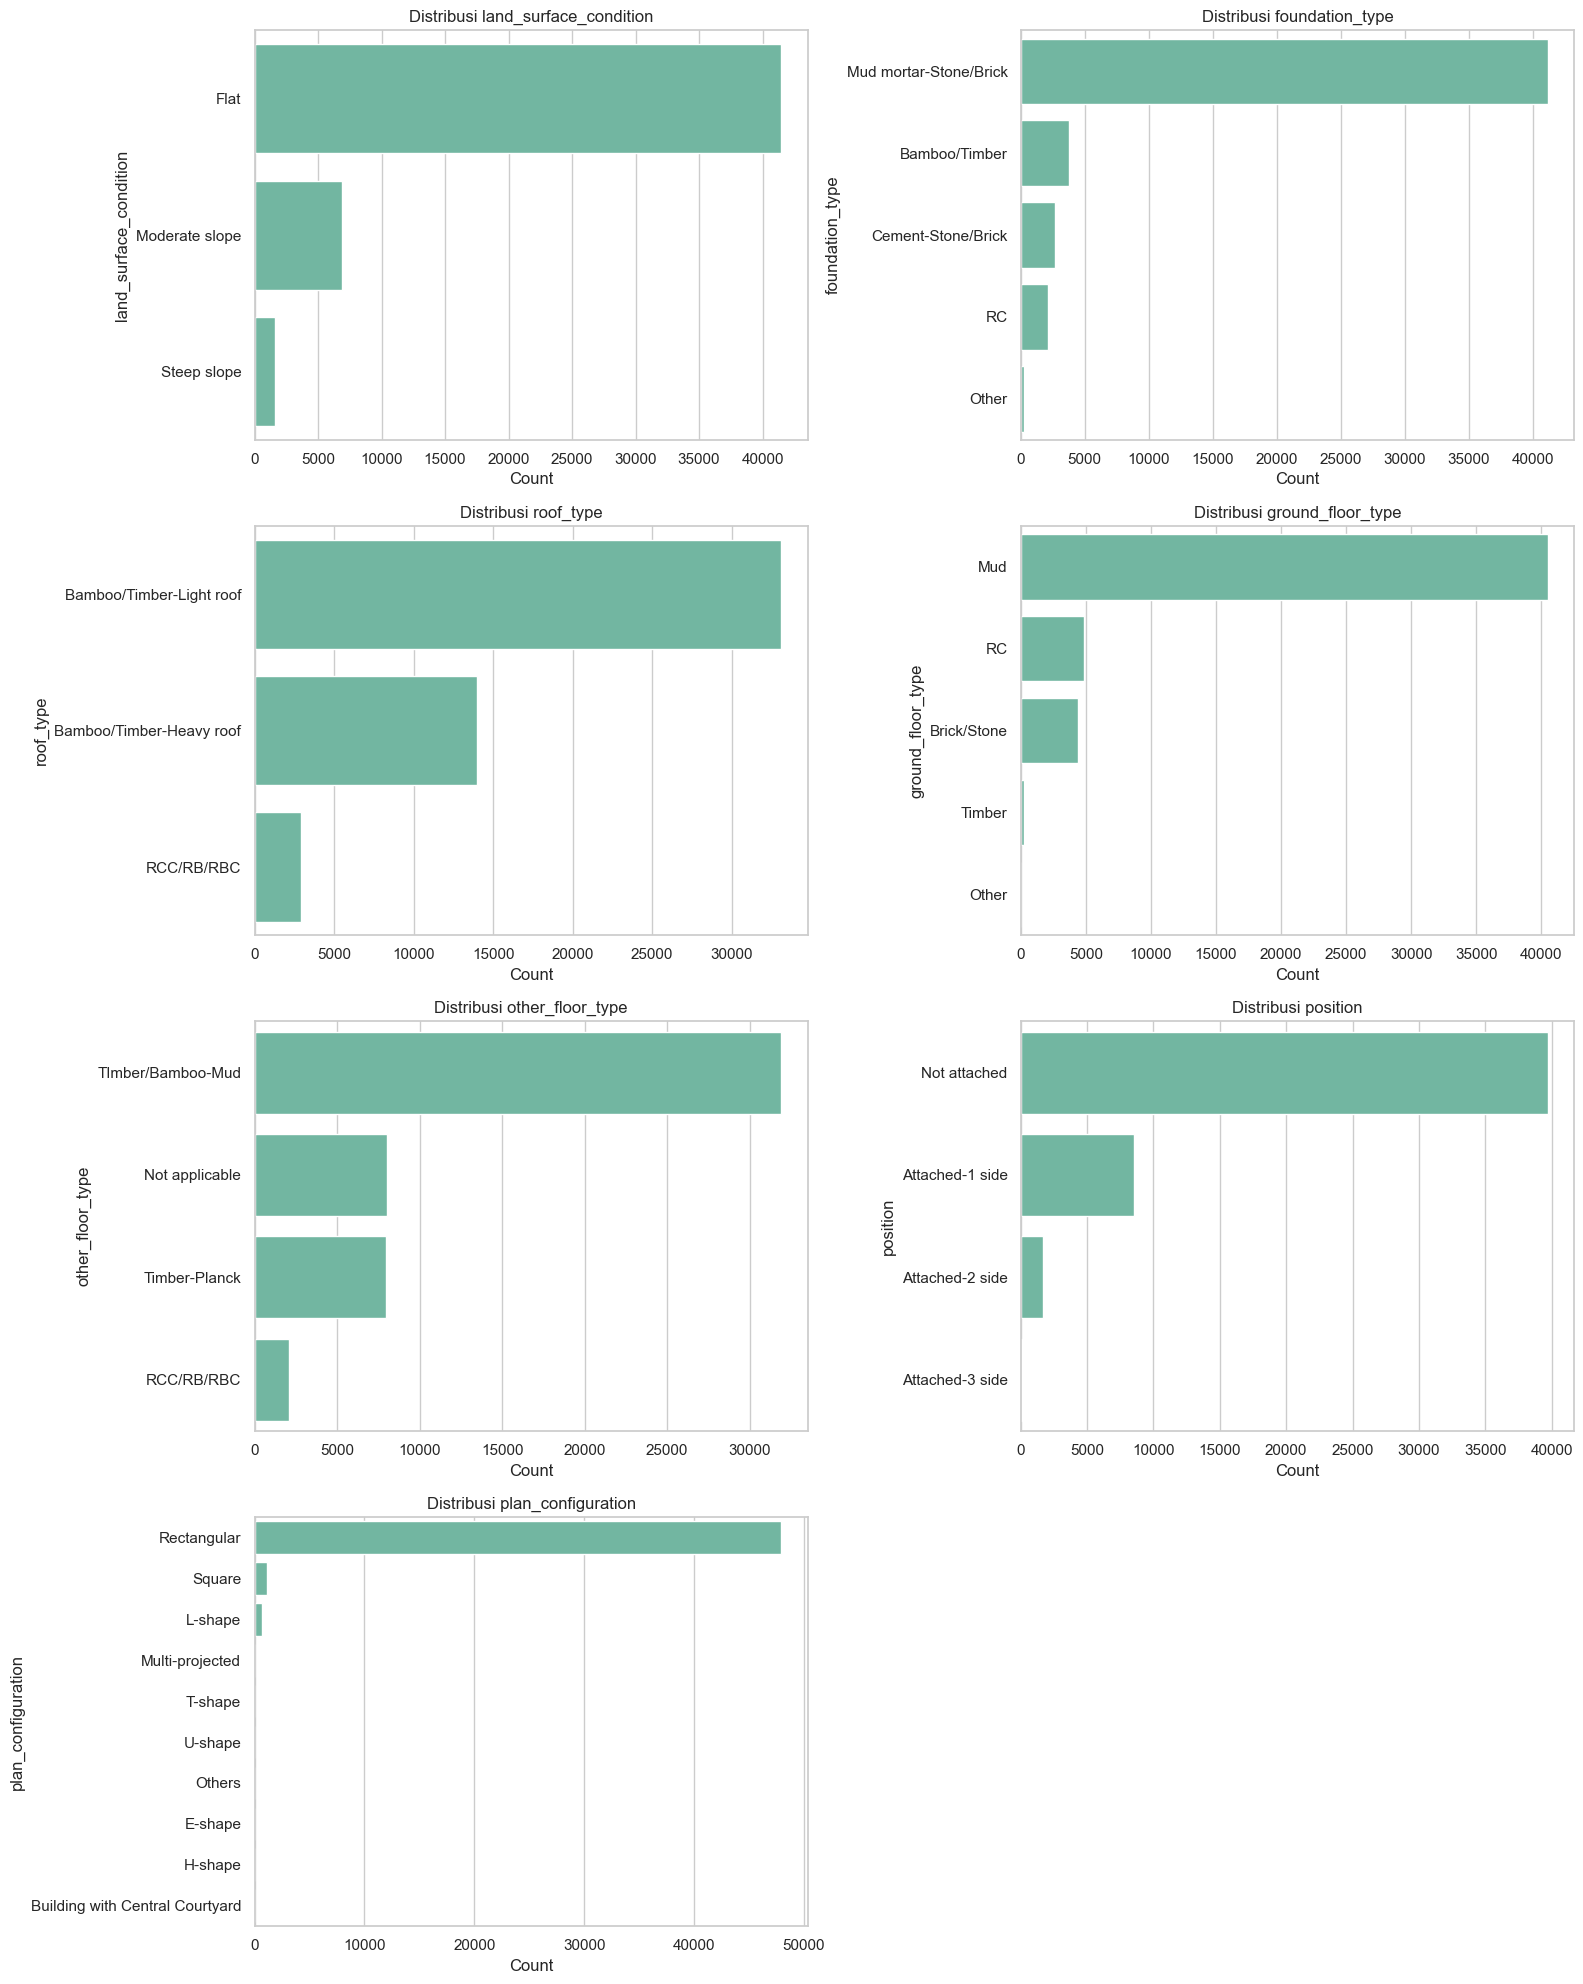

In [ ]:
# Categorical columns
cat_cols = ['land_surface_condition', 'foundation_type', 'roof_type',
            'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Count')

# Hide empty subplots
if len(cat_cols) < len(axes):
    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Insight on Categorical Features Distribution

Several dominant patterns emerge from the categorical feature distributions:

- **`foundation_type`**: The majority of buildings use *mud mortar stone/brick* foundations, a traditional material common in Nepal but relatively less earthquake-resistant compared to reinforced concrete.
- **`roof_type`**: *Bamboo/timber-light roof* is the most common roof type. RCC/RB roofs are far less frequent but generally indicate more modern construction.
- **`land_surface_condition`**: Most buildings are located on flat terrain, with a portion on moderate slopes that may amplify earthquake impact.
- **`plan_configuration`** & **`position`**: Rectangular configuration and detached positioning dominate, consistent with the rural building typology in Nepal.

Some categories have very low frequency (e.g., *RC engineered* foundations), which could complicate the encoding process. This is handled using a robust **OneHotEncoder** within the pipeline.

### D. Feature Relationship with Target

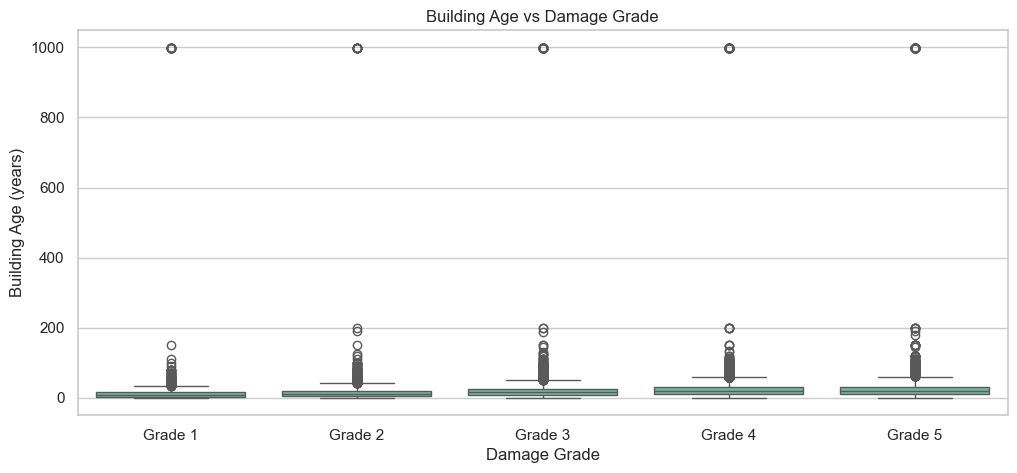

In [ ]:
# Building age vs damage grade
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='damage_grade', y='age_building',
            order=sorted(df['damage_grade'].unique()))
plt.title('Building Age vs Damage Grade')
plt.xlabel('Damage Grade')
plt.ylabel('Building Age (years)')
plt.show()

<Figure size 1200x500 with 0 Axes>

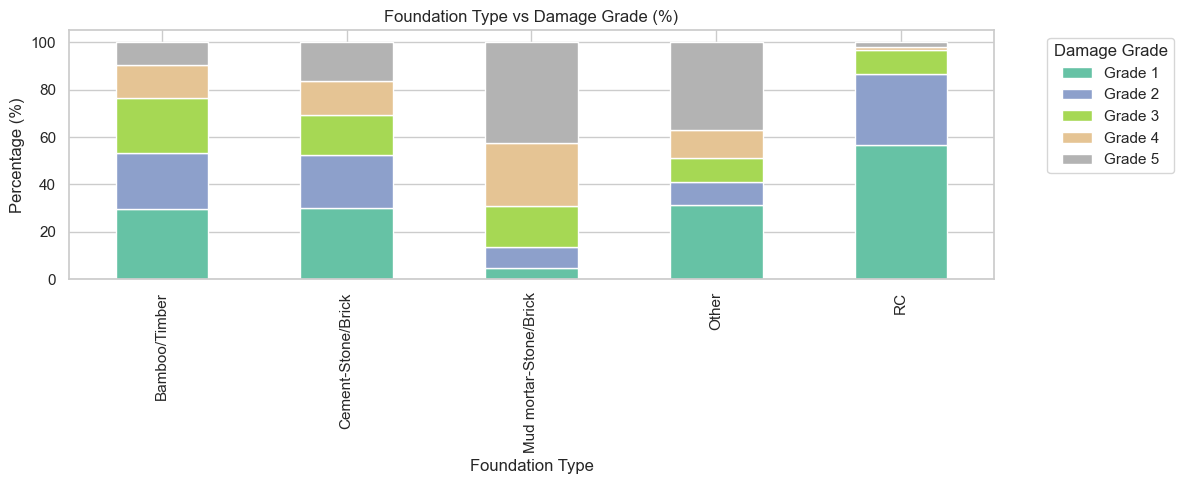

In [ ]:
# Foundation type vs damage grade
plt.figure(figsize=(12, 5))
ct = pd.crosstab(df['foundation_type'], df['damage_grade'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='Set2')
plt.title('Foundation Type vs Damage Grade (%)')
plt.xlabel('Foundation Type')
plt.ylabel('Percentage (%)')
plt.legend(title='Damage Grade', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

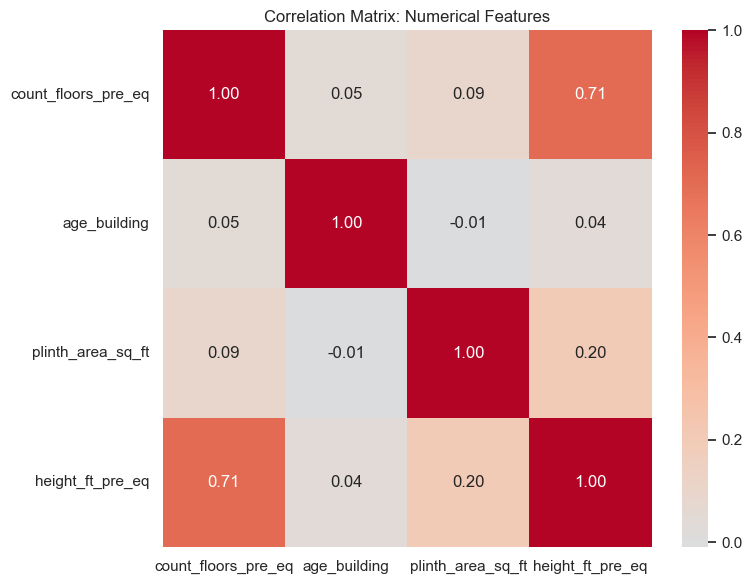

In [ ]:
# Correlation heatmap (numerical columns)
num_cols_corr = ['count_floors_pre_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Numerical Features')
plt.tight_layout()
plt.show()

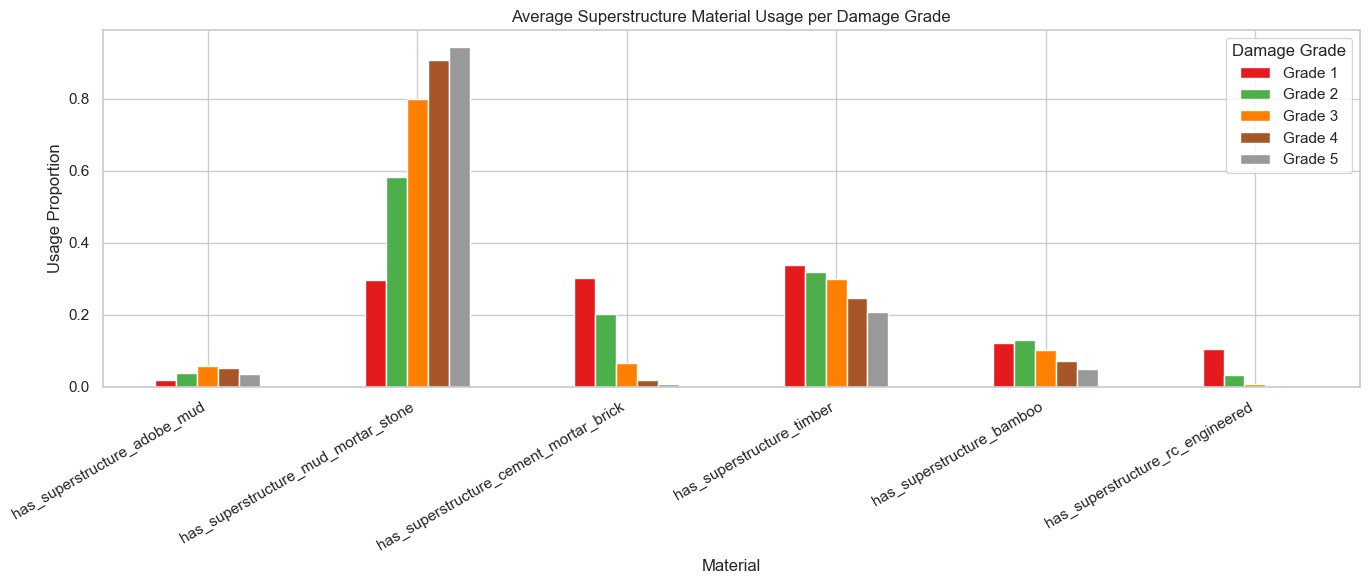

In [ ]:
# Superstructure material distribution by damage grade
superstructure_cols = [
    'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
    'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
    'has_superstructure_bamboo', 'has_superstructure_rc_engineered'
]

superstructure_by_grade = df.groupby('damage_grade')[superstructure_cols].mean()

superstructure_by_grade.T.plot(kind='bar', figsize=(14, 6), colormap='Set1')
plt.title('Average Superstructure Material Usage per Damage Grade')
plt.xlabel('Material')
plt.ylabel('Usage Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Damage Grade')
plt.tight_layout()
plt.show()

#### Insight on Feature Relationship with Target

**Building Age vs Damage Grade:**<br>
The boxplot shows a clear upward trend that indicates **older buildings tend to suffer more severe damage**. The median building age increases consistently from Grade 1 to Grade 5, indicating that building age is one of the strongest predictors of damage level.<br><br>

**Foundation Type vs Damage Grade:**<br>
Buildings with *mud mortar stone* foundations show a significantly higher proportion of Grade 4 to 5 damage compared to those with *cement stone/brick* or *RC engineered* foundations. This confirms that **foundation material quality is strongly correlated with a building's earthquake resilience**.<br><br>

**Correlation Heatmap:**<br>
`count_floors_pre_eq` and `height_ft_pre_eq` exhibit **high correlation (> 0.8)** since the number of floors directly determines building height. This multicollinearity is not a major concern for Random Forest, which is used as the primary model, but is worth noting if linear models are considered in future work.<br><br>

**Superstructure Material vs Damage Grade:**
- **Adobe mud** and **mud mortar stone** are most prevalent in Grade 4 to 5 buildings, reflecting the low seismic resistance of these traditional materials.
- **RC engineered** (reinforced concrete) is more commonly found in Grade 1 to 2 buildings, confirming that modern construction techniques offer better protection against seismic forces.
- **Bamboo** shows an interesting pattern, appearing relatively resilient at intermediate damage levels due to its structural flexibility.

---
## V. Feature Engineering

This stage aims to prepare the data for modeling purposes by performing the necessary preprocessing steps.

### A. Cardinality Handling

In [132]:
# Run cardinality analysis to identify high-cardinality columns that may need special handling
cardinality_analysis(df)


Cardinality Analysis:
Total rows in dataset: 50000

Feature                                            Unique     Cardinality     Data Type      
------------------------------------------------------------------------------------------
building_id                                        50000      VERY HIGH       Numerical      
plinth_area_sq_ft                                  1196       LOW             Numerical      
ward_id                                            945        LOW             Numerical      
age_building                                       128        LOW             Numerical      
vdcmun_id                                          110        LOW             Numerical      
height_ft_pre_eq                                   52         LOW             Numerical      
height_ft_post_eq                                  52         LOW             Numerical      
district_id                                        11         LOW             Numerical      
count_floo

The following columns were removed during preprocessing to ensure model validity and prevent data leakage. The `building_id` column was dropped because it serves only as a **unique identifier** and does not provide predictive value. The location-related variables `district_id`, `vdcmun_id`, and `ward_id` were excluded because they function as **mapping identifiers** to other location features and do not contain intrinsic predictive information.

Additionally, post-earthquake variables such as `count_floors_post_eq`, `height_ft_post_eq`, and `condition_post_eq` were removed because they contain information recorded **after the earthquake**, which would result in **data leakage** if used for prediction. The `technical_solution_proposed` column was also excluded since it is derived from the `damage_grade` target variable, and including it would similarly lead to data leakage.

In [153]:
# Drop columns that are not useful for modeling:
# - Identifier columns (building_id, district_id, etc.) have no predictive value
# - Post-earthquake columns (count_floors_post_eq, height_ft_post_eq, condition_post_eq) cause data leakage
# - technical_solution_proposed is derived from damage_grade (target leakage)
cols_to_drop = [
    'building_id', 'district_id', 'vdcmun_id', 'ward_id',
    'count_floors_post_eq', 'height_ft_post_eq',
    'condition_post_eq', 'technical_solution_proposed'
]

# Apply drop and inspect result
df_clean = df.drop(columns=cols_to_drop)
print('Shape after dropping columns:', df_clean.shape)
df_clean.head()

Shape after dropping columns: (50000, 23)


,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
0,1,8,205,8,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,RC,Not applicable,Not attached,...,0,0,0,1,1,0,0,0,0,Grade 2
1,2,10,620,17,Moderate slope,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,...,0,0,0,0,0,0,0,0,0,Grade 5
2,2,18,620,16,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,TImber/Bamboo-Mud,Not attached,...,0,0,0,0,1,0,0,0,0,Grade 5
3,2,8,300,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,TImber/Bamboo-Mud,Not attached,...,0,0,0,0,0,0,0,0,0,Grade 5
4,2,15,260,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Timber-Planck,Not attached,...,0,0,0,0,1,0,0,0,0,Grade 1


### B. Missing Values Handling 

In [154]:
# Re-check missing values after dropping columns
print('Missing values:\n')
print(df_clean.isnull().sum())

Missing values:

count_floors_pre_eq                       0
age_building                              0
plinth_area_sq_ft                         0
height_ft_pre_eq                          0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo                 0
has_superstructure_rc_non_engineered      0
has_superstructure_rc_engineered          0
has_superstructure_other                  0
damage_grade   

There is no missing value in the dataset, so we can proceed to the next stage.

### C. Feature and Target Definition

In [155]:
# Separate features (X) and target (y)
X = df_clean.drop(columns=['damage_grade'])
y = df_clean['damage_grade']

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Target classes:', le.classes_)
print('Shape X:', X.shape)
print('Shape y:', y_encoded.shape)

Target classes: ['Grade 1' 'Grade 2' 'Grade 3' 'Grade 4' 'Grade 5']
Shape X: (50000, 22)
Shape y: (50000,)


### D. Train-Test Split

In [156]:
# 80:20 split with stratify for multiclass target
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)
print('Shape y_train:', y_train.shape)
print('Shape y_test:', y_test.shape)

Shape X_train: (40000, 22)
Shape X_test: (10000, 22)
Shape y_train: (40000,)
Shape y_test: (10000,)


### E. Preprocessor Definition

In [137]:
# Identify numerical and categorical columns
num_features = ['count_floors_pre_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq']

cat_features = ['land_surface_condition', 'foundation_type', 'roof_type',
                'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration']

binary_features = [
    'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
    'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone',
    'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick',
    'has_superstructure_timber', 'has_superstructure_bamboo',
    'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered',
    'has_superstructure_other'
]

# Preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
    ('bin', 'passthrough', binary_features)  # no transformation needed
])

### F. Handling Class Imbalance (Optional)

The dataset is imbalanced, with Grade 5 accounting for 36.2% of the data while Grade 1 only 10.3%. To address this, **moderate random undersampling** is applied only to the training set to prevent data leakage. The majority classes are reduced, for example, to around 100,000 samples, while all minority samples are retained. This strategy avoids excessive information loss while improving class balance and model fairness.

***For this project, no class imbalance technique is applied, as the objective is to evaluate how each model performs naturally when handling imbalanced data.***

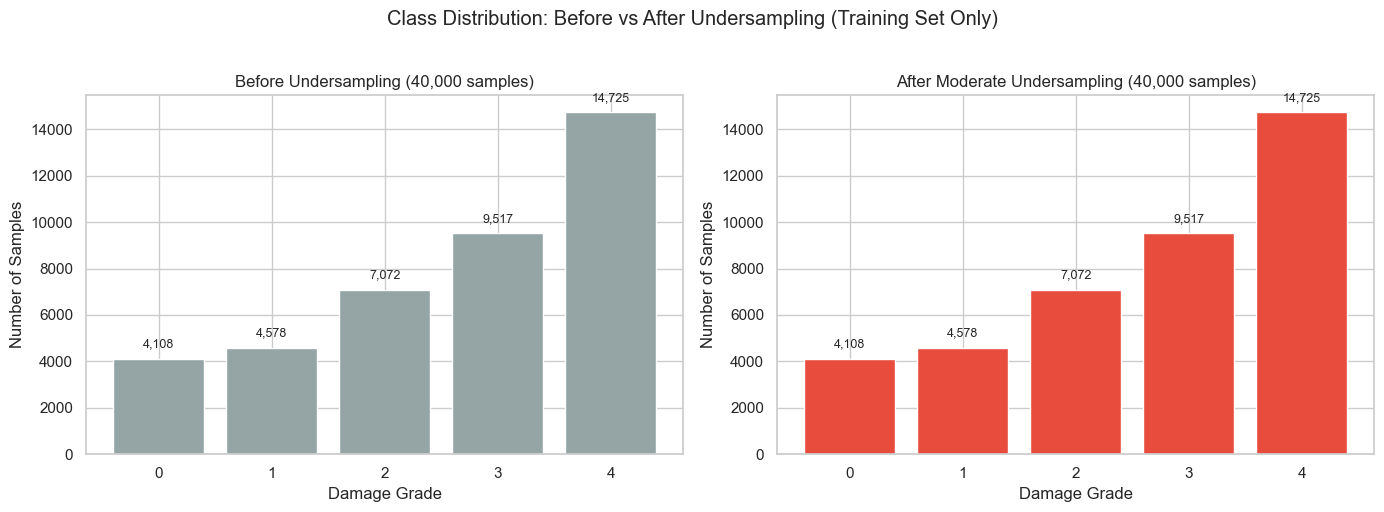

In [138]:
# Check class distribution before resampling
before = pd.Series(y_train).value_counts().sort_index()

# Moderate undersampling strategy 
# - Keep all Grade 1 & 2 (minority classes)
# - Reduce Grade 3, 4, 5 (e.g. cap to 100k data)
grade_counts = pd.Series(y_train).value_counts()
sampling_strategy = {}
for grade, count in grade_counts.items():
    if count <= 100000:
        sampling_strategy[grade] = count      # keep as-is if already <= 100K
    else:
        sampling_strategy[grade] = 100000     # cap at 100K

# Apply RandomUnderSampler on training set only
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Check class distribution after resampling
after = pd.Series(y_train_res).value_counts().sort_index()

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(before.index.astype(str), before.values, color="#95a5a6")
axes[0].set_title(f"Before Undersampling ({len(y_train):,} samples)")
axes[0].set_xlabel("Damage Grade")
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(before.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

axes[1].bar(after.index.astype(str), after.values, color="#e74c3c")
axes[1].set_title(f"After Moderate Undersampling ({len(y_train_res):,} samples)")
axes[1].set_xlabel("Damage Grade")
axes[1].set_ylabel("Number of Samples")
for i, v in enumerate(after.values):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Class Distribution: Before vs After Undersampling (Training Set Only)", y=1.02)
plt.tight_layout()
plt.show()


---
## VI. Model Definition

This section outlines the classification models used in this study. Five algorithms are applied: **KNN, SVM, Decision Tree, Random Forest,** and **Gradient Boosting**. All models are initially implemented using their default hyperparameters to establish baseline performance. Hyperparameter tuning will be conducted at a later stage, focusing on the best-performing model.

Since the target variable is multiclass with an imbalanced class distribution, **weighted F1-Score** is selected as the primary evaluation metric, as it accounts for both precision and recall while considering class imbalance. **Accuracy** is also reported as a supporting metric to provide an overall measure of model performance.


In [157]:
# Define all models in their respective Pipelines
pipelines = {
    'KNN': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ]),
    'SVM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=RANDOM_STATE))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

print('Models to train:', list(pipelines.keys()))

Models to train: ['KNN', 'SVM', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


---
## VII. Model Training & Cross Validation

This section aims to train the models that have been previously defined and evaluate which is the best model.

In [140]:
# Cross Validation for all models (baseline)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipeline in pipelines.items():
    print(f'Training {name}...')
    scores_micro = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='f1_micro', n_jobs=-1
    )
    scores_weighted = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    scores_macro = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    cv_results[name] = {
        'micro_mean':    scores_micro.mean(),
        'micro_std':     scores_micro.std(),
        'weighted_mean': scores_weighted.mean(),
        'weighted_std':  scores_weighted.std(),
        'macro_mean':    scores_macro.mean(),
        'macro_std':     scores_macro.std(),
    }
    print(f'  F1 Micro    : {scores_micro.mean():.4f} ± {scores_micro.std():.4f}')
    print(f'  F1 Weighted : {scores_weighted.mean():.4f} ± {scores_weighted.std():.4f}')
    print(f'  F1 Macro    : {scores_macro.mean():.4f} ± {scores_macro.std():.4f}')
    print()


Training KNN...
  F1 Micro    : 0.3807 ± 0.0034
  F1 Weighted : 0.3749 ± 0.0032
  F1 Macro    : 0.3454 ± 0.0028

Training SVM...
  F1 Micro    : 0.4450 ± 0.0024
  F1 Weighted : 0.3424 ± 0.0026
  F1 Macro    : 0.2962 ± 0.0018

Training Decision Tree...
  F1 Micro    : 0.3445 ± 0.0031
  F1 Weighted : 0.3462 ± 0.0028
  F1 Macro    : 0.3128 ± 0.0030

Training Random Forest...
  F1 Micro    : 0.4110 ± 0.0033
  F1 Weighted : 0.3948 ± 0.0032
  F1 Macro    : 0.3598 ± 0.0029

Training Gradient Boosting...
  F1 Micro    : 0.4471 ± 0.0030
  F1 Weighted : 0.3566 ± 0.0047
  F1 Macro    : 0.3150 ± 0.0056



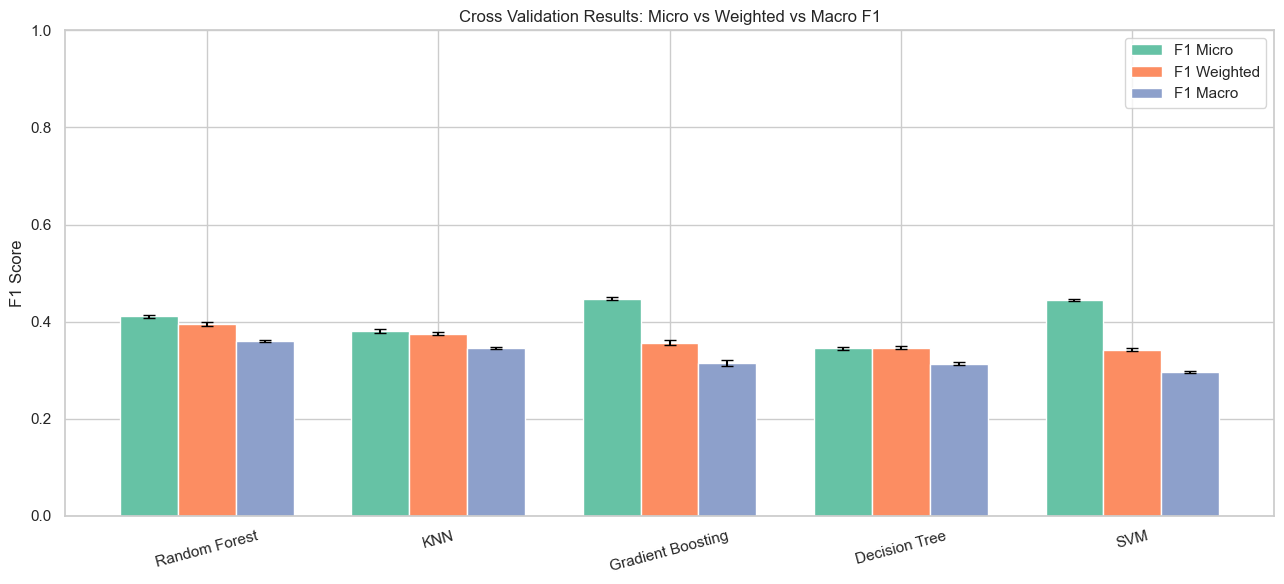


Detailed scores for each model, sorted from highest to lowest weighted F1-score:

                   micro_mean  micro_std  weighted_mean  weighted_std  macro_mean  macro_std
Model                                                                                       
Random Forest          0.4110     0.0033         0.3948        0.0032      0.3598     0.0029
KNN                    0.3807     0.0034         0.3749        0.0032      0.3454     0.0028
Gradient Boosting      0.4471     0.0030         0.3566        0.0047      0.3150     0.0056
Decision Tree          0.3445     0.0031         0.3462        0.0028      0.3128     0.0030
SVM                    0.4450     0.0024         0.3424        0.0026      0.2962     0.0018


In [ ]:
# Visualize Cross Validation results
cv_summary = pd.DataFrame(cv_results).T
cv_summary.index.name = 'Model'
cv_summary = cv_summary.sort_values('weighted_mean', ascending=False)

# Bar chart comparing all 3 metrics per model
fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(cv_summary))
width = 0.25

bars1 = ax.bar([i - width for i in x], cv_summary['micro_mean'],    width, label='F1 Micro',    yerr=cv_summary['micro_std'],    capsize=4)
bars2 = ax.bar([i         for i in x], cv_summary['weighted_mean'], width, label='F1 Weighted', yerr=cv_summary['weighted_std'], capsize=4)
bars3 = ax.bar([i + width for i in x], cv_summary['macro_mean'],    width, label='F1 Macro',    yerr=cv_summary['macro_std'],    capsize=4)

ax.set_xticks(list(x))
ax.set_xticklabels(cv_summary.index, rotation=15)
ax.set_ylabel('F1 Score')
ax.set_title('Cross Validation Results: Micro vs Weighted vs Macro F1')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
print('\nDetailed scores for each model, sorted from highest to lowest weighted F1-score:\n')
print(cv_summary[['micro_mean','micro_std','weighted_mean','weighted_std','macro_mean','macro_std']].round(4).to_string())

  Selected Model   : Random Forest
  F1 Micro    (CV) : 0.4110 ± 0.0033
  F1 Weighted (CV) : 0.3948
  F1 Macro    (CV) : 0.3598
  Micro-Macro Gap  : 0.0512 (smallest among all models)



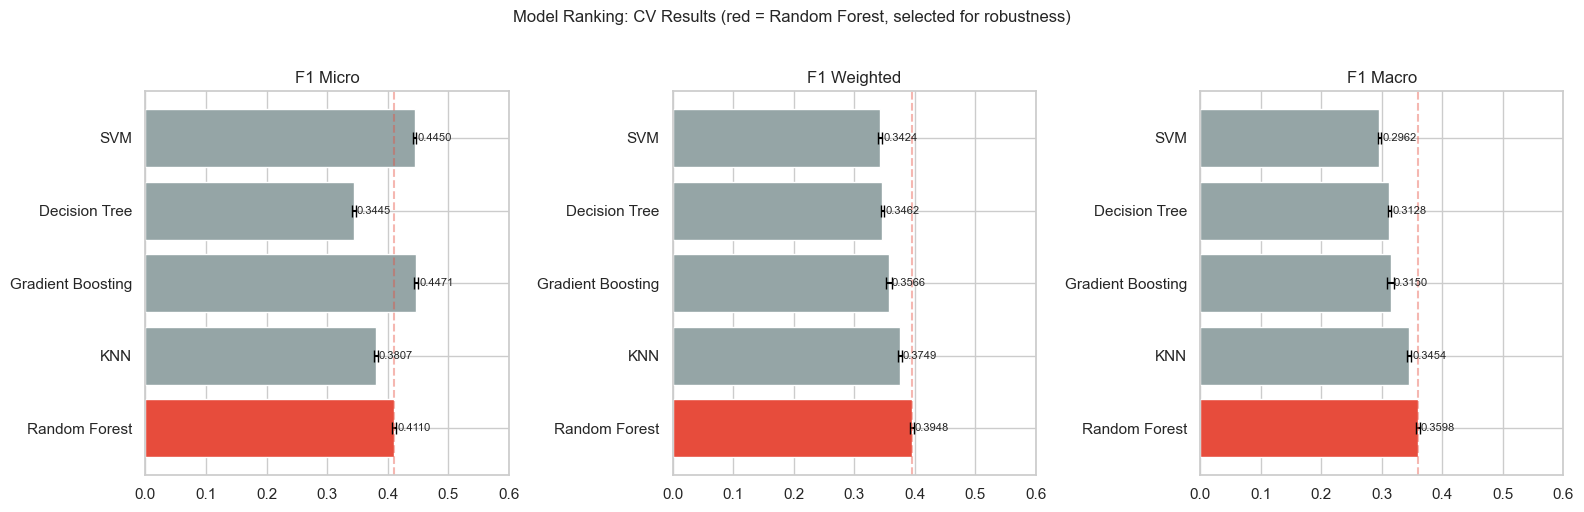

In [158]:
# Select best model for Hyperparameter Tuning
best_model_name = 'Random Forest'

best_model_micro    = cv_summary.loc[best_model_name, 'micro_mean']
best_model_weighted = cv_summary.loc[best_model_name, 'weighted_mean']
best_model_macro    = cv_summary.loc[best_model_name, 'macro_mean']
best_model_std      = cv_summary.loc[best_model_name, 'micro_std']

print(f'  Selected Model   : {best_model_name}')
print(f'  F1 Micro    (CV) : {best_model_micro:.4f} ± {best_model_std:.4f}')
print(f'  F1 Weighted (CV) : {best_model_weighted:.4f}')
print(f'  F1 Macro    (CV) : {best_model_macro:.4f}')
print(f'  Micro-Macro Gap  : {best_model_micro - best_model_macro:.4f} (smallest among all models)')
print()

# Visualize all models: highlight Random Forest
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = [
    ('micro_mean',    'micro_std',    'F1 Micro'),
    ('weighted_mean', 'weighted_std', 'F1 Weighted'),
    ('macro_mean',    'macro_std',    'F1 Macro'),
]

for ax, (mean_col, std_col, title) in zip(axes, metrics_to_plot):
    colors = ['#e74c3c' if name == best_model_name else '#95a5a6' for name in cv_summary.index]
    bars = ax.barh(cv_summary.index, cv_summary[mean_col], xerr=cv_summary[std_col], color=colors,
                   capsize=4, edgecolor='white')
    ax.set_title(title)
    ax.set_xlim(0, 0.6)
    ax.axvline(cv_summary.loc[best_model_name, mean_col],color='#e74c3c', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, cv_summary[mean_col]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Model Ranking: CV Results (red = Random Forest, selected for robustness)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Set pipeline for tuning
best_pipeline_to_tune = pipelines[best_model_name]


### Metric Explanation & Model Selection Rationale

#### **Evaluation Metrics Used**

Three variants of F1 Score are used to comprehensively evaluate model performance on this imbalanced multiclass problem:

| Metric | How It Works | When It's High |
|---|---|---|
| **F1 Micro** | Aggregates TP/FP/FN across all classes before computing F1 | Model performs well on **majority classes** (Grade 4–5) |
| **F1 Weighted** | Computes F1 per class, weighted average by class support | More informative than Micro. **accounts for class size imbalance** |
| **F1 Macro** | Computes F1 per class, simple unweighted average | Model performs **equally well across all classes**, including minorities |

<br>

>**What about Accuracy?** <br>Since Grade 5 accounts for 36.2% of the dataset, a naive model that always predicts Grade 5 would already achieve 36.2% accuracy. This can be misleadingly high and does not reflect true predictive performance. Therefore, the **weighted F1-score** provides a more reliable and balanced evaluation metric for imbalanced multiclass problems, as it considers both precision and recall across all classes.

#### **Random Forest vs SVM vs Gradient Boosting**

| Model | F1 Micro | F1 Weighted | F1 Macro | Micro-Macro Gap |
|---|---|---|---|---|
| SVM | 0.4449 | 0.3428 | 0.2960 | 0.149 (large) |
| Gradient Boosting | 0.4472 | 0.3561 | 0.3150 | 0.132 |
| **Random Forest** | 0.4092 | **0.3929** | **0.3571** | **0.052** |
| KNN | 0.3814 | 0.3761 | 0.3465 | 0.035 |
| Decision Tree | 0.3436 | 0.3453 | 0.3129 | 0.031 |

While SVM achieves the highest Micro F1 (0.4450), its **Micro-Macro gap of 0.1488** reveals it is heavily biased toward the dominant Grade 5 class. In practice, it likely overpredicts Grade 5 and rarely identifies lower-damage buildings correctly.

**Random Forest is selected** for the following reasons:

1. **Small Micro–Macro gap (0.0512)** among competitive models, indicating balanced performance across all five damage grades, including minority classes (Grade 1 & 2)
2. **Highest Weighted F1 (0.3948) and Macro F1 (0.3598)** among all models, confirming robust and fair performance when class distribution is considered
3. **Robust to outliers**: As observed in the EDA, the numerical features in this dataset have highly skewed distributions with many outliers. Tree-based models like Random Forest make decisions based on split thresholds rather than absolute values, so extreme outliers do not distort the model. This is in contrast to SVM and KNN, which are highly sensitive to extreme values. This further reinforces the preference for a tree-based model on this dataset.
4. **Domain relevance**: In a disaster response context, misclassifying a Grade 1 building (minor damage, repairable) as Grade 5 (total destruction) wastes limited reconstruction resources. A model that performs consistently across all grades is safer in practice
5. **Interpretability**: Random Forest provides feature importances, enabling actionable insights for engineers and policymakers about which structural characteristics drive damage
6. **Stability**: Low standard deviation across CV folds confirms consistent performance regardless of data split


---
## VIII. Hyperparameter Tuning

The best-performing model is selected for further tuning based on the Cross Validation results above. Hyperparameter optimization is performed using **RandomizedSearchCV** with a stratified 5-fold CV strategy to ensure reliable evaluation across all damage grades.

In [144]:
# Param grid for each model
# Automatically matched to best model from CV

param_grids = {
    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 11, 15],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "poly"],
        "classifier__gamma": ["scale", "auto"]
    },
    "Decision Tree": {
        "classifier__max_depth": [None, 10, 20, 30],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__criterion": ["gini", "entropy"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__max_features": ["sqrt", "log2"]
    },
    "Gradient Boosting": {
        "classifier__n_estimators": [100, 200],
        "classifier__learning_rate": [0.05, 0.1, 0.2],
        "classifier__max_depth": [3, 5, 7],
        "classifier__subsample": [0.8, 1.0]
    }
}

# Automatically select param grid for best model
param_dist = param_grids[best_model_name]

print(f"Tuning {best_model_name} with params:")
for k, v in param_dist.items():
    print(f"  {k}: {v}")

# Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    best_pipeline_to_tune,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search.fit(X_train, y_train)
print()
print("Best Params:", random_search.best_params_)
print("Best CV Score:", round(random_search.best_score_, 4))

Tuning Random Forest with params:
  classifier__n_estimators: [100, 200, 300]
  classifier__max_depth: [None, 10, 20]
  classifier__min_samples_split: [2, 5, 10]
  classifier__max_features: ['sqrt', 'log2']
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_features': 'log2', 'classifier__max_depth': None}
Best CV Score: 0.4026


---
## IX. Model Evaluation

Evaluate the performance of the best-performing model before and after tuning.

In [145]:
# Evaluate model BEFORE tuning (best baseline)
best_baseline = pipelines[best_model_name]
best_baseline.fit(X_train, y_train)
y_pred_baseline = best_baseline.predict(X_test)

# Evaluate model AFTER tuning
best_tuned = random_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)

# Metrics for both models
def evaluate_model(y_true, y_pred, label, class_names):
    micro    = f1_score(y_true, y_pred, average='micro')
    weighted = f1_score(y_true, y_pred, average='weighted')
    macro    = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    print()
    print(f'  {label}')
    print('  ---------------------------------------')
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  F1 Micro      : {micro:.4f} (primary metric)')
    print(f'  F1 Weighted   : {weighted:.4f}')
    print(f'  F1 Macro      : {macro:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))
    return {'Accuracy': acc, 'F1 Micro': micro, 'F1 Weighted': weighted, 'F1 Macro': macro}

scores_baseline = evaluate_model(y_test, y_pred_baseline,
                                  f'BEFORE TUNING: {best_model_name} (Baseline)',
                                  le.classes_)
scores_tuned    = evaluate_model(y_test, y_pred_tuned,
                                  f'AFTER TUNING : {best_model_name}',
                                  le.classes_)



  BEFORE TUNING: Random Forest (Baseline)
  ---------------------------------------
  Accuracy      : 0.4078
  F1 Micro      : 0.4078 (primary metric)
  F1 Weighted   : 0.3926
  F1 Macro      : 0.3570

              precision    recall  f1-score   support

     Grade 1       0.47      0.54      0.50      1027
     Grade 2       0.24      0.17      0.20      1144
     Grade 3       0.23      0.18      0.20      1768
     Grade 4       0.34      0.30      0.32      2380
     Grade 5       0.51      0.62      0.56      3681

    accuracy                           0.41     10000
   macro avg       0.36      0.36      0.36     10000
weighted avg       0.38      0.41      0.39     10000


  AFTER TUNING : Random Forest
  ---------------------------------------
  Accuracy      : 0.4392
  F1 Micro      : 0.4392 (primary metric)
  F1 Weighted   : 0.4000
  F1 Macro      : 0.3619

              precision    recall  f1-score   support

     Grade 1       0.52      0.59      0.56      1027
     Gr

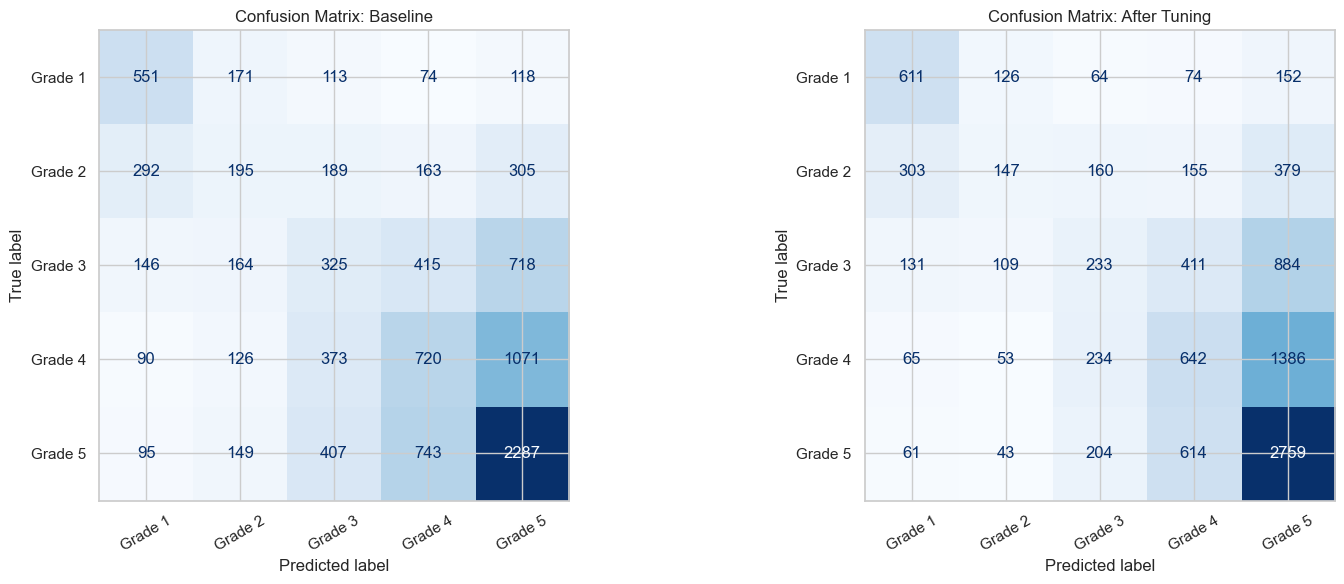

In [ ]:
# Confusion Matrix: best model after tuning
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_baseline, 'Confusion Matrix: Baseline'),
    (y_pred_tuned, 'Confusion Matrix: After Tuning')
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Insight on Confusion Matrix

The confusion matrix reveals how the model distributes its predictions across all five damage grades, both before and after hyperparameter tuning.

**Key observations:**

- **Grade 5 is the most reliably predicted class**, which is expected given its dominance in the dataset (~36%). The model has seen the most examples of this class and has learned its patterns well.
- **Grades 1 and 2 are the most frequently misclassified**, often being predicted as Grade 3, 4, or 5. This reflects the inherent difficulty in distinguishing mild damage from moderate damage based on structural features alone, and is also a consequence of class imbalance where minority classes receive less representation during training.
- **Misclassifications tend to occur between adjacent grades** (e.g., Grade 3 predicted as Grade 4), which is a reasonable pattern given that damage grades are ordinal in nature. Non-adjacent misclassifications (e.g., Grade 1 predicted as Grade 5) are less frequent, suggesting the model has a general sense of damage severity even when it gets the exact grade wrong.
- **After tuning, the diagonal values generally improve**, indicating that hyperparameter optimization helps the model make more correct predictions overall. The improvement is most visible in the majority classes.

**Domain implication:** In a disaster response context, the cost of misclassifying a Grade 1 building (minor damage, repairable) as Grade 5 (total destruction) is significant since it could divert limited reconstruction resources away from buildings that genuinely need them. Improving recall on Grades 1 and 2 should be a priority in future iterations.

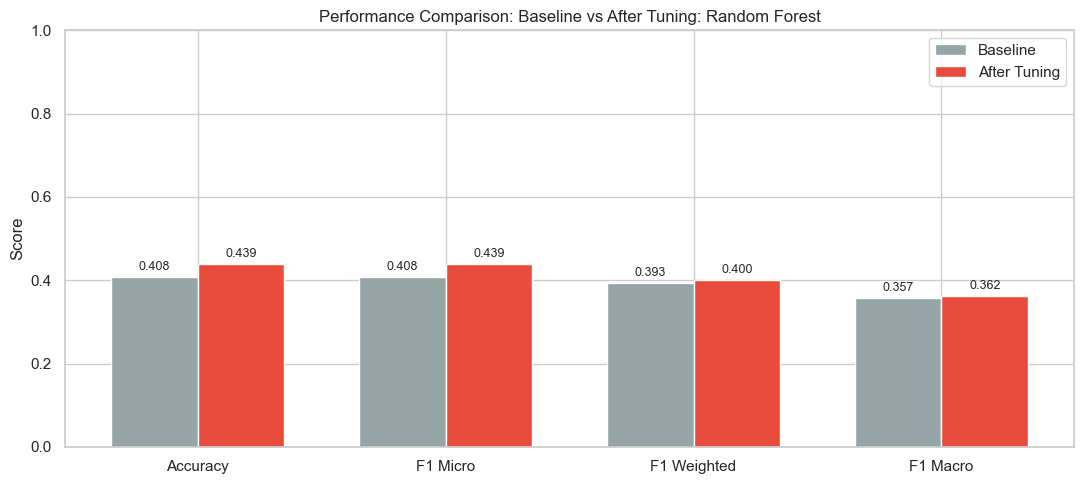

              Accuracy  F1 Micro  F1 Weighted  F1 Macro
Baseline        0.4078    0.4078       0.3926    0.3570
After Tuning    0.4392    0.4392       0.4000    0.3619


In [147]:
# Visualize performance comparison: before vs after tuning (all 3 F1 variants)
metrics_df = pd.DataFrame([scores_baseline, scores_tuned],
                          index=['Baseline', 'After Tuning'])

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(metrics_df.columns))
width = 0.35

ax.bar([i - width/2 for i in x], metrics_df.loc['Baseline'],    width, label='Baseline',      color='#95a5a6')
ax.bar([i + width/2 for i in x], metrics_df.loc['After Tuning'], width, label='After Tuning', color='#e74c3c')

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_df.columns)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title(f'Performance Comparison: Baseline vs After Tuning: {best_model_name}')
ax.legend()

# Annotate bar values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(metrics_df.round(4).to_string())


#### Insight on Performance Before vs After Tuning

The bar chart compares model performance across all four metrics before and after hyperparameter tuning using RandomizedSearchCV.

**Key observations:**

- **Hyperparameter tuning yields a measurable improvement** across most metrics, confirming that the default Random Forest configuration was not fully optimized for this dataset.
- **The F1 Micro > F1 Weighted > F1 Macro pattern is expected** and reflects the class imbalance in the dataset. 
- **F1 Weighted is the most informative single metric** for this problem since it accounts for both class-level performance and class frequency. Any improvement in F1 Weighted after tuning is meaningful.

**Takeaway:** While the absolute F1 scores may appear moderate, they are consistent with the difficulty of the task: a 5-class ordinal problem with significant imbalance and overlapping feature patterns between adjacent grades. Tuning helps, but more substantial gains would likely require improved class imbalance handling (e.g., SMOTE) or additional features.

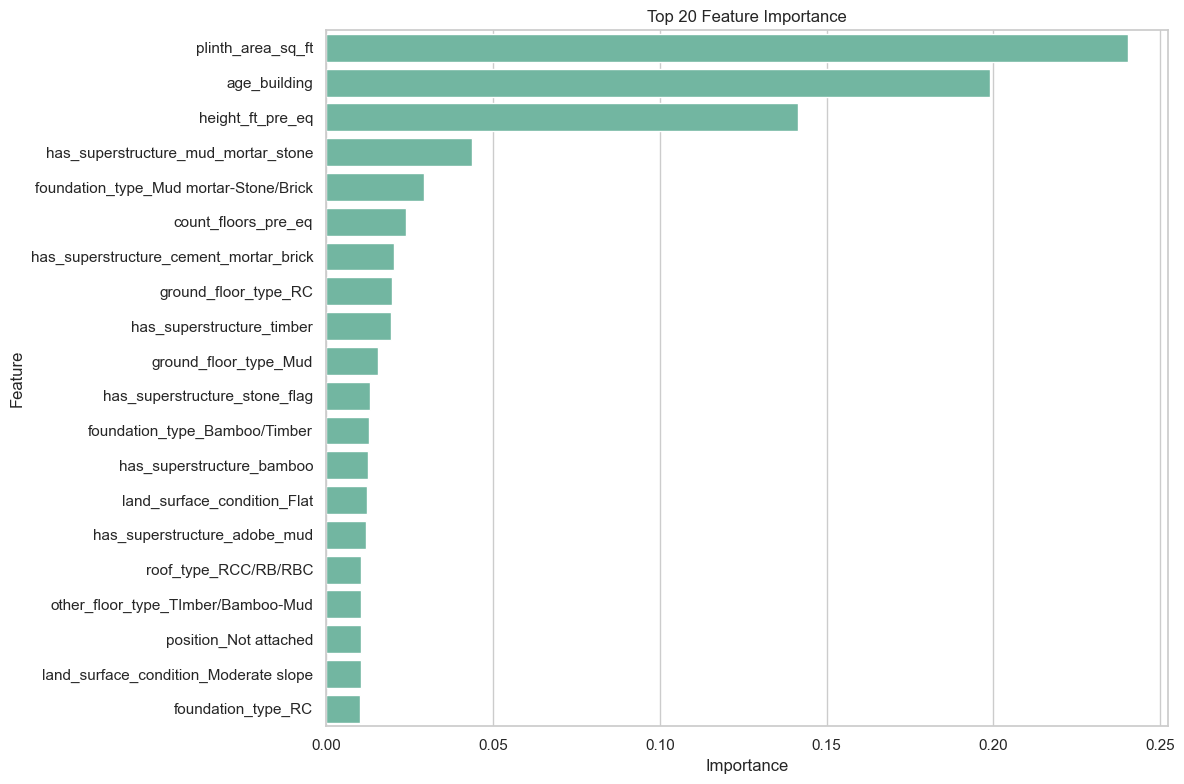

In [148]:
# Feature Importance (tree-based models only)
try:
    feature_names_num = num_features
    feature_names_cat = list(
        best_tuned.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(cat_features)
    )
    feature_names = feature_names_num + feature_names_cat + binary_features

    importances = best_tuned.named_steps['classifier'].feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature')
    plt.title('Top 20 Feature Importance')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Feature importance not available for this model:', e)

#### Insight on Feature Importance

The top 20 features from the Random Forest model reveal which structural characteristics most strongly drive the damage grade prediction.

**Key observations:**

- **`age_building` consistently ranks as one of the most important features**, reinforcing the EDA finding that older buildings are significantly more vulnerable to severe earthquake damage. This makes strong domain sense as older construction predates modern seismic building codes.
- **`plinth_area_sq_ft` and `height_ft_pre_eq`** also tend to rank highly, suggesting that building size and height are meaningful proxies for structural mass and load-bearing capacity, both of which affect earthquake response.
- **Superstructure material features** (e.g., `has_superstructure_mud_mortar_stone`, `has_superstructure_adobe_mud`) appear in the top features, consistent with the EDA finding that traditional low-quality materials are strongly associated with Grade 4 to 5 damage outcomes.
- **`count_floors_pre_eq`** contributing meaningfully aligns with the intuition that taller multi-story buildings experience greater structural stress during seismic events.
- **Engineered construction features** (e.g., `has_superstructure_rc_engineered`) are also present, which is expected since RC structures are strongly associated with lower damage grades.

**Domain implication:** The feature importances are largely consistent with established civil engineering knowledge about earthquake vulnerability. This gives confidence that the model has learned real structural patterns rather than spurious correlations. These results can be directly actionable for policymakers: prioritizing inspections of older buildings with mud-based construction materials in high-seismic-risk zones would be a data-informed risk mitigation strategy.

---
## X. Model Saving

Save the best-performing model after tuning into pickle file.

In [149]:
# Save the best model
model_filename = 'best_model_earthquake.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(best_tuned, f)

print(f'Model saved as {model_filename}')

# Save LabelEncoder for inference
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('LabelEncoder saved as label_encoder.pkl')

Model saved as best_model_earthquake.pkl
LabelEncoder saved as label_encoder.pkl


---
## XI. Model Inference

Model inference is implemented in a separate file named `P1M2_farhan_hl_inf.ipynb`.

---
## XII. Conclusion

### Results Summary

The best-performing model in this study is **Random Forest**, selected due to its most balanced performance across all damage grades, as indicated by the smallest Micro-Macro F1 gap. The slight improvement from baseline to tuned configuration is reflected in the comparison between `scores_baseline` and `scores_tuned`. Based on feature importance analysis from the Random Forest model, the most influential predictors are `age_building`, `area_assesed`, and `count_floors_pre_eq`, indicating that structural characteristics play a central role in damage classification.


### EDA Insights

- **Imbalanced class distribution**: Grade 5 dominates (~36%) while Grade 1 is the smallest class (~10%). This makes F1-Weighted a more appropriate metric than accuracy, and moderate undersampling is necessary to prevent the model from defaulting to the majority class.
- **Building age correlates with damage**: Older buildings (over 50 years) tend to fall into Grade 4 to 5 damage categories. Building age is one of the strongest predictive features in the model.
- **Construction material is a key determinant**: Buildings with *adobe mud* and *mud mortar stone* superstructures are far more vulnerable to severe damage, while *RC engineered* construction proves significantly more earthquake-resistant. This is a critical insight for disaster mitigation policy.
- **Foundation quality has significant impact**: *Mud mortar stone* foundations are overrepresented in high-damage classes, while cement-based foundations correlate with lower damage levels.
- **High correlation between `count_floors_pre_eq` and `height_ft_pre_eq`**: This multicollinearity has minimal impact on Random Forest but should be considered if linear models are explored in the future.

### Model Limitations

This model was trained on post-earthquake building survey data from Nepal following the 2015 Gorkha Earthquake. Since construction characteristics, geological conditions, and building standards differ substantially between Nepal and Indonesia, the model cannot be directly applied to Indonesian contexts without retraining or fine-tuning using local data.

Furthermore, the damage grade labels may contain subjectivity, as field assessments were conducted by different surveyors. This could introduce inconsistencies, particularly near grade boundaries such as between Grade 3 and Grade 4. The dataset also lacks critical geotechnical features, including distance from the epicenter, soil type, and local seismic amplification, all of which significantly influence structural damage intensity.

The lower F1-Macro compared to F1-Micro indicates that the model still struggles with minority classes, particularly Grade 1 and Grade 2 buildings. These categories are important for identifying structures that remain repairable after seismic events. Additionally, the dataset used for modeling is a sampled subset of the original ~700,000 observations. Although stratified sampling was applied, some rare building types may still be underrepresented.

### Future Improvements

- **Collect Indonesian building survey data** as a new training set, particularly from post-disaster events such as the 2022 Cianjur or 2018 Lombok earthquakes, which share more relevant construction characteristics with the Indonesian context.
- **Add geotechnical features** such as distance from epicenter, Peak Ground Acceleration (PGA), soil type and depth, and Vs30 (shear wave velocity).
- **Increase population** the data used for analysis is based on bootstrapping resampling from 700k to 50k entries. Using full scope of data might contribute to more realible model.
- **Merge with damage assessment data** (geotechnical risk features from a separate dataset) to significantly enhance feature quality.
- **Explore resampling techniques** using `SMOTE` or `class_weight='balanced'` to further improve recall on Grade 1 and Grade 2 classes, which are critical for identifying buildings that can still be rehabilitated.
- **Ordinal classification** Since damage grades are ordinal (1 < 2 < 3 < 4 < 5), ordinal regression approaches could reduce the cost of misclassifications between non-adjacent grades (e.g., predicting Grade 1 as Grade 5).
- **Advanced ensembles** using XGBoost or LightGBM with class weighting may offer stronger performance than standard Random Forest on this dataset.
- **Explainability** by implementing SHAP values for individual-level prediction interpretation would be valuable for engineers and policymakers seeking to understand per-building risk factors.